In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report,precision_recall_curve, auc
from sklearn.model_selection import StratifiedKFold, cross_val_score,cross_val_predict
data = pd.read_csv("A1_dataB.tsv", sep="\t") 
#Check data
print(data.head())


         X1        X2        X3        X4        X5  class
0  0.509022  0.977143  1.807426 -0.456832  1.114991      1
1  0.431006  0.340303 -0.991420 -0.533280  0.033497      1
2  0.601544  1.627891 -0.144424  0.070053  0.485216      1
3 -0.346139  0.435936  1.240060  0.286332  0.475602      1
4  1.669372  0.390462  1.225110 -0.809030  0.088785      1


In [87]:
data_nonscaled=data.copy()
#Scale Data
scaler = StandardScaler()
data[["X1","X2","X3","X4","X5"]]= scaler.fit_transform(data[["X1","X2","X3","X4","X5"]])
data

,X1,X2,X3,X4,X5,class
0,0.284022,0.188969,1.594390,-1.021875,1.181415,1
1,0.181587,-0.634490,-2.078744,-1.131885,-0.602341,1
2,0.405502,1.030412,-0.967168,-0.263671,0.142700,1
3,-0.838795,-0.510832,0.849794,0.047562,0.126842,1
4,1.807547,-0.569632,0.830174,-1.528698,-0.511152,1
...,...,...,...,...,...,...
95,-0.241094,-0.329125,0.204290,1.038276,-1.282378,0
96,0.883753,-0.622298,0.272855,1.553129,-0.950601,0
97,-0.102854,0.033297,0.271449,1.482466,-0.443852,0
98,-2.039249,0.057718,-0.134582,-0.387463,-0.892640,0


In [88]:

#Melt for seaborn
data_graph = data.melt(
    id_vars=data.columns[-1],
    value_vars=data.columns[:-1],
    var_name="Feature",
    value_name="Value"
)


In [89]:
#We have two classes
# pd.set_option('display.max_rows',None)
# data[data["class"]==1]

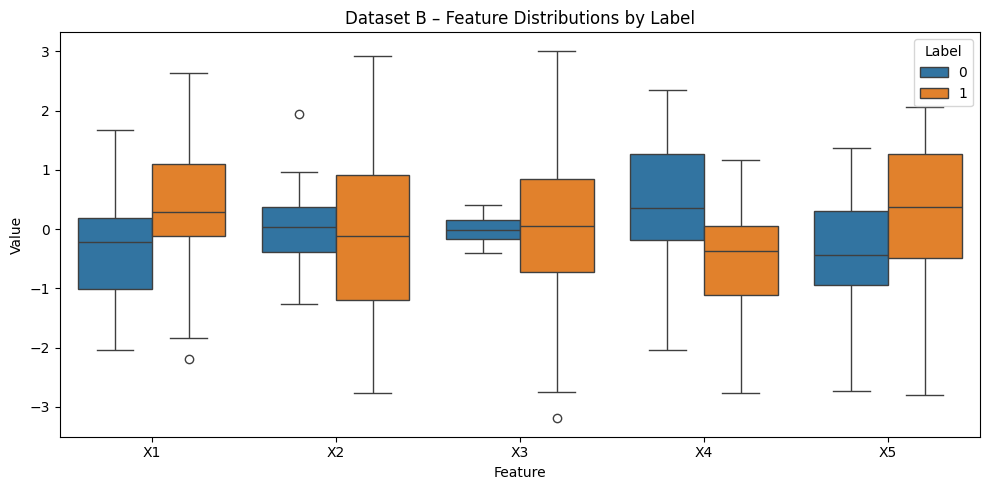

In [90]:
#Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(
    x="Feature",
    y="Value",
    hue=data.columns[-1],
    data=data_graph
)
plt.title("Dataset B – Feature Distributions by Label")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

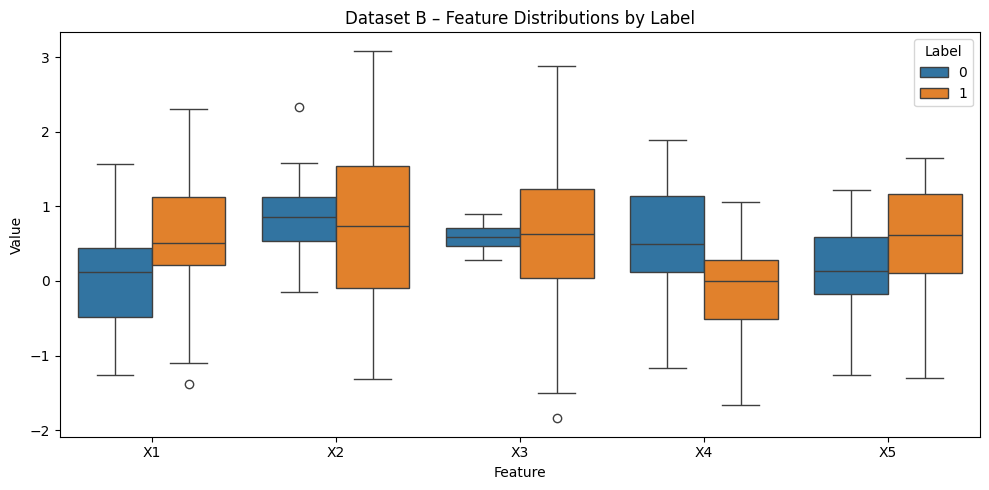

In [91]:
dataB = pd.read_csv("A1_dataB.tsv", sep="\t")

dataB_graph = dataB.melt(
    id_vars=dataB.columns[-1],
    value_vars=dataB.columns[:-1],
    var_name="Feature",
    value_name="Value"
)

plt.figure(figsize=(10, 5))
sns.boxplot(
    x="Feature",
    y="Value",
    hue=dataB.columns[-1],
    data=dataB_graph
)

plt.title("Dataset B – Feature Distributions by Label")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.legend(title="Label")
plt.tight_layout()
plt.show()


In [92]:
data.index

RangeIndex(start=0, stop=100, step=1)

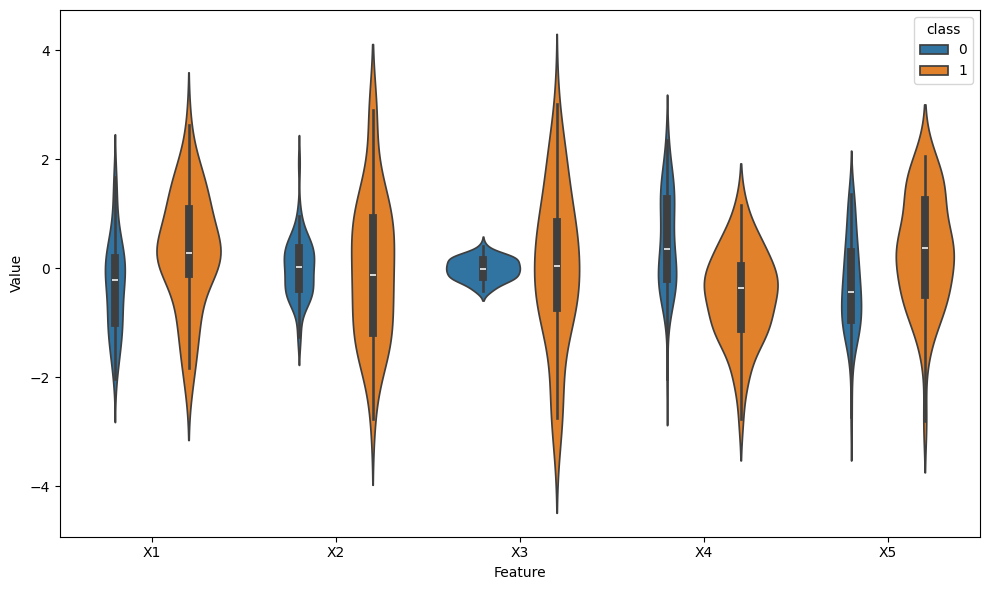

In [93]:
#Violin plot
plt.figure(figsize=(10, 6))
violinplt=sns.violinplot(data=data_graph, x="Feature",y="Value",hue="class",legend=True)
plt.tight_layout()
plt.show()

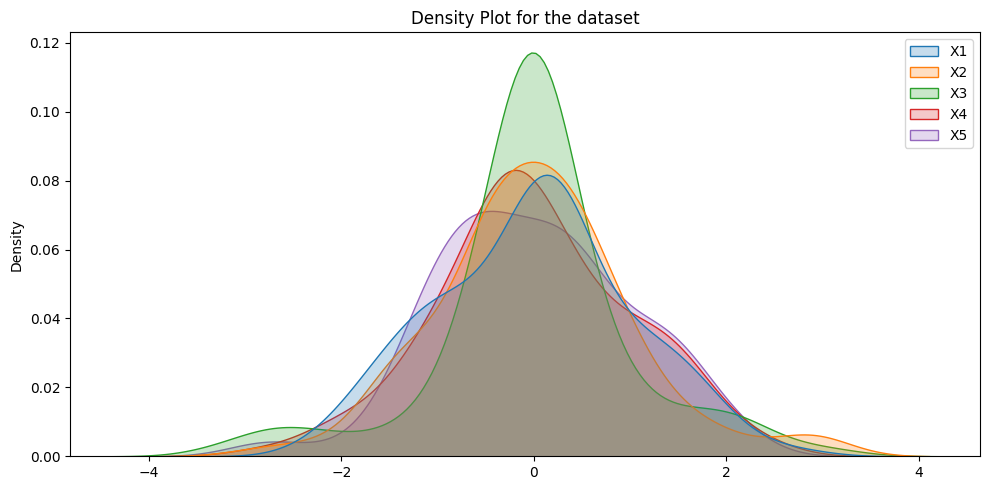

In [94]:
#Density Plot
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=pd.DataFrame(data[["X1","X2","X3","X4","X5"]]),
    fill=True,
    legend=True,
)
plt.title("Density Plot for the dataset")
plt.tight_layout()
plt.show()

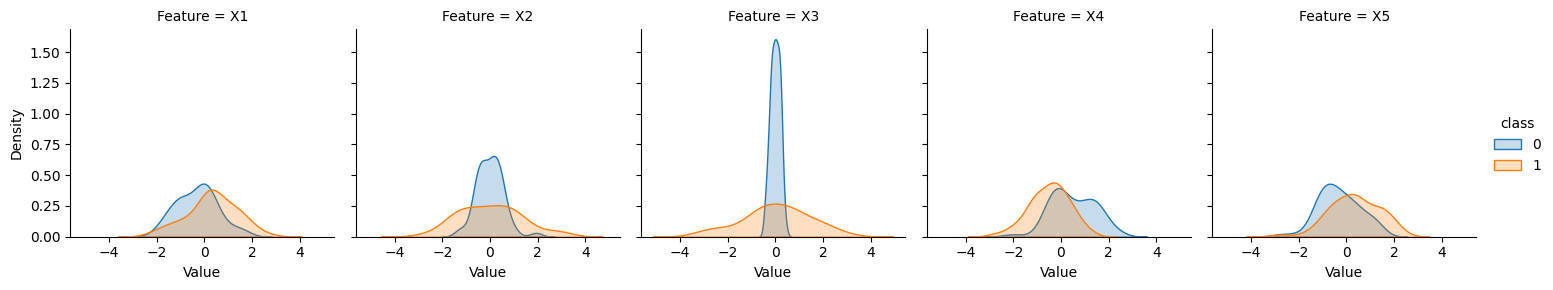

In [95]:
density_plot_with_class=sns.FacetGrid(data_graph, col="Feature", hue="class", col_wrap=5, sharex=True)
density_plot_with_class.map(sns.kdeplot, "Value", fill=True)
density_plot_with_class.add_legend()
plt.show()

Dataset B does show some overlap between different features, however in comparisson to Dataset A it is more statistically stable. We note that features X2, X3 and X4 are the most informative features here as they clearly highlight the differences between the two classes. For instance, feature X3 has a clear concentration of class 0 values around zero. Similarly, feature X2 as well has Class 0 values concentrated around the mean(zero) albeit these are more widely spread here. Feature X4 on the other hand shows a clear difference in means between the two classes which can be leveraged in our KNN model.
### Therefore, our hypothesis is that the KNN Model produced using this data will perform reasonably well.

In [96]:
# for i, (train_index, test_index) in enumerate(skf.split(X, Y)):
#     print(train_index)
#     print(test_index)

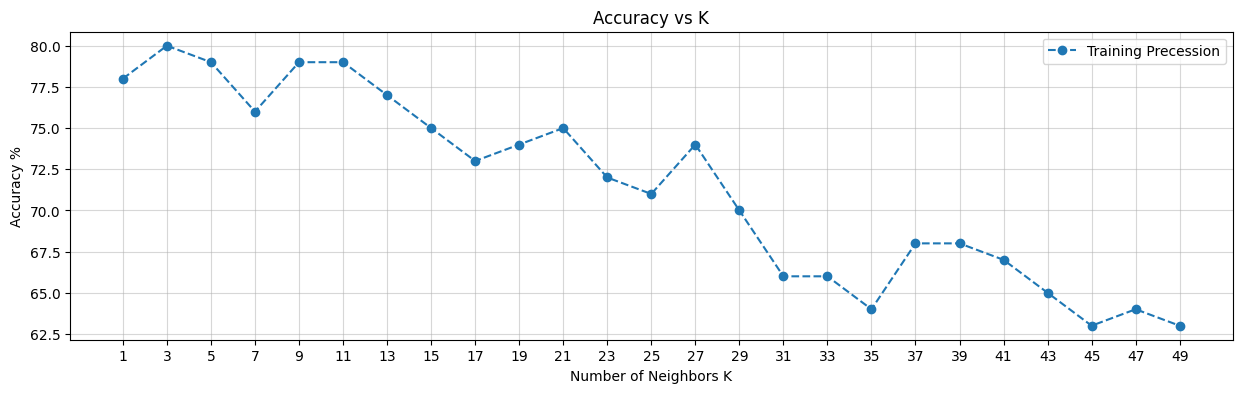

In [97]:
X=data[["X1","X2","X3","X4","X5"]]
Y=data["class"]
k_values = range(1, 51, 2)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
model_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    #testing accuracies
    model_score= cross_val_score(model,X,Y,cv=skf,scoring="accuracy")
    model_accuracies.append(model_score.mean()*100)


plt.figure(figsize=(15,4))
plt.plot(k_values, model_accuracies, label='Training Precession', marker='o', linestyle='--')

plt.title('Accuracy vs K')
plt.xlabel('Number of Neighbors K')
plt.ylabel('Accuracy %')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

In [98]:
#We choose K=3 based on the above
knn=KNeighborsClassifier(n_neighbors=3)
def run_skf_knn(knn,X,Y):
    cv_results_accuracy = cross_val_score(knn, X, Y, cv=skf, scoring='accuracy')
    cv_results_average_precision = cross_val_score(knn, X, Y, cv=skf, scoring='average_precision')
    cv_results_f1 = cross_val_score(knn, X, Y, cv=skf, scoring='f1')
    cv_results_precision = cross_val_score(knn, X, Y, cv=skf, scoring='precision')
    cv_results_recall = cross_val_score(knn, X, Y, cv=skf, scoring='recall')
    print(f"Average Precesion: {cv_results_average_precision.mean()}")
    print(f"Accuracy: {cv_results_accuracy.mean():.4f}")
    print(f"F1-score: {cv_results_f1.mean():.4f}")
    print(f"Precision: {cv_results_precision.mean():.4f}")
    print(f"Recall: {cv_results_recall.mean():.4f}")
    return skf

skf=run_skf_knn(knn,X,Y)

Average Precesion: 0.8543095238095239
Accuracy: 0.8000
F1-score: 0.7777
Precision: 0.8633
Recall: 0.7200


In [99]:
#We choose K=30
skf=run_skf_knn(KNeighborsClassifier(n_neighbors=5),X,Y)


Average Precesion: 0.8723571428571428
Accuracy: 0.7900
F1-score: 0.7683
Precision: 0.8505
Recall: 0.7200


As we can see all metrics including F1 score and Recall are significantly higher here than in case of Dataset A. Confirming our hypothesis.

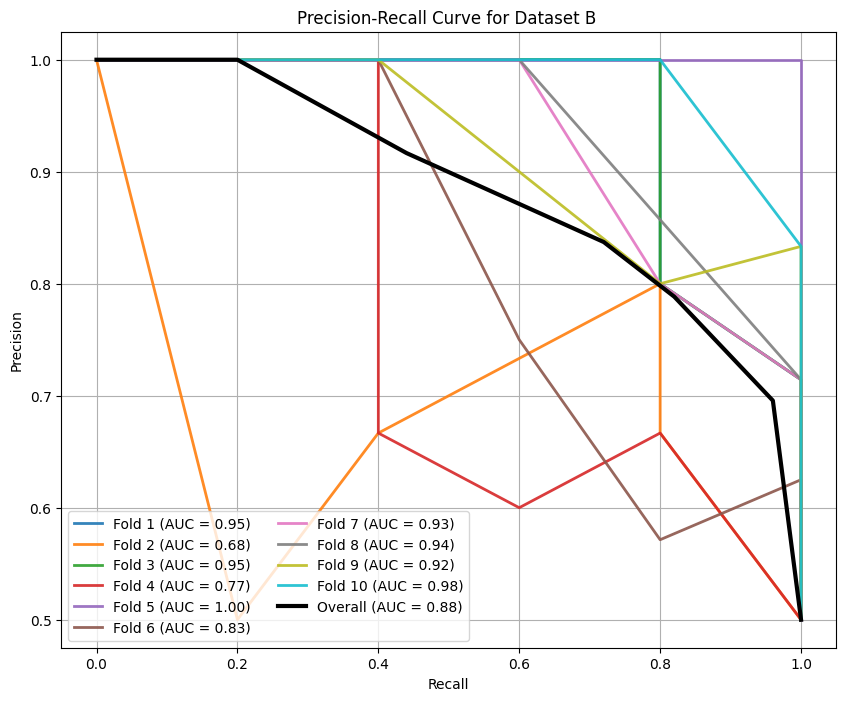

In [100]:
def plot_pr_curve_per_fold(model, X, Y,skf,text=""):
    plt.figure(figsize=(10, 8))
    
    for i, (train_index, test_index) in enumerate(skf.split(X, Y)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]
        
        model.fit(X_train, y_train)
        y_probas = model.predict_proba(X_test)[:, 1]
        
        precision, recall, _ = precision_recall_curve(y_test, y_probas)
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, lw=2, alpha=0.9, label=f'Fold {i+1} (AUC = {pr_auc:.2f})')
        # if(i==0):
        #     break

    y_probas_all = cross_val_predict(model, X, Y, cv=skf, method='predict_proba')[:, 1]
    
    precision_all, recall_all, _ = precision_recall_curve(Y, y_probas_all)
    all_auc = auc(recall_all, precision_all)
    
    #overall curve
    plt.plot(recall_all, precision_all, color='black', lw=3, label=f'Overall (AUC = {all_auc:.2f})')
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f"Precision-Recall Curve for Dataset B {text}")
    plt.legend(loc='best', fontsize='medium', ncol=2)
    plt.grid(True)
    
    plt.show()

knn = KNeighborsClassifier(n_neighbors=5) 
plot_pr_curve_per_fold(knn, X, Y,skf)

As expected, the overall AUPRC is 0.88 which is a sign of a stable model that generalizes well.

In [101]:
#Now lets test our hypothesis that only three of the 5 features which are more informative.
X=data[["X2","X3","X4"]]
Y=data["class"]
knn=KNeighborsClassifier()
skf=run_skf_knn(knn,X,Y)

Average Precesion: 0.9263333333333333
Accuracy: 0.8800
F1-score: 0.8606
Precision: 0.9467
Recall: 0.8000


As we can see the accuracy actually improved by removing the other features indicating that they were simply adding to the noise for the model.

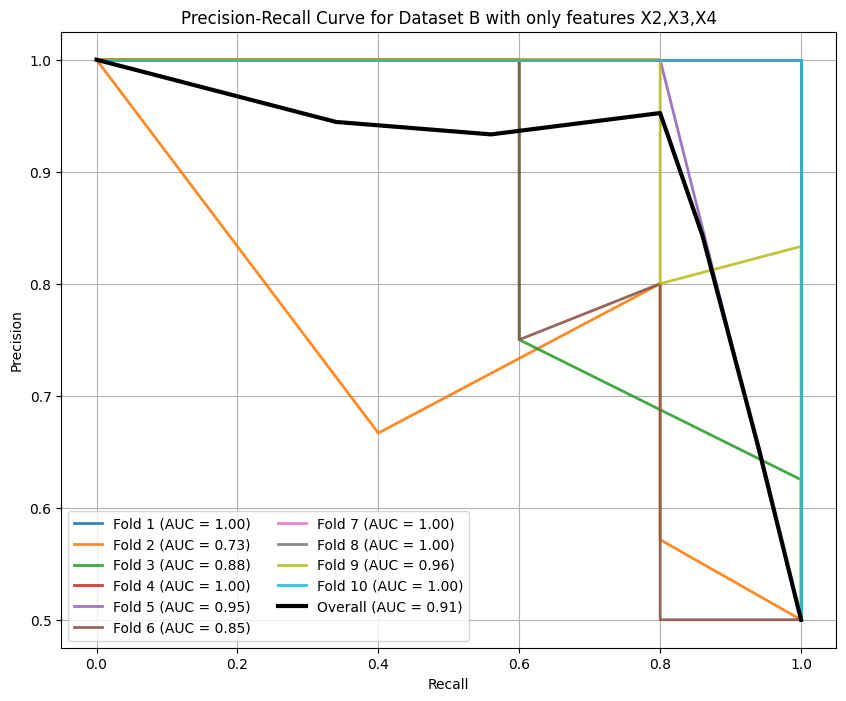

In [102]:

knn = KNeighborsClassifier(n_neighbors=5) 
plot_pr_curve_per_fold(knn, X, Y,skf, "with only features X2,X3,X4")

Dropping the overlapping features we get the above, as we can see the AUC has gone up. The overall AUC is now 0.91 which is evidence of a stable model. This furtehr confirms our hypothesis that features X1 and X5 were adding noise to the dataset.